In [1]:
# %% [markdown]
# # ACC102 Python Data Product Assignment
# Student Name: [Yongzhuo.Li]
# Student ID: [2468612]
# Selected Track: Track 2 - Github Data Analysis Project
# Analysis Theme: Apple Inc. Stock Performance Trend Analysis

In [2]:
# %% [markdown]
# ## 1. Problem Definition & Project Objective
# - **Analytical Problem**: Explore the historical price movement, volatility and return characteristics of Apple stock between 2023–2025
# - **Target User**: Beginner-level investors, business/finance undergraduate students
# - **Project Purpose**: Demonstrate complete Python data analysis workflow, generate actionable educational investment insights

In [3]:
# %% [markdown]
# ## 2. Dataset Introduction
# - This project uses a simulated but market-realistic AAPL stock dataset (2023–2025, business trading days)
# - Fully offline, no external API/network dependency, no download failure or rate limit error
# - Contains complete Date, Open/High/Low/Close price and trading volume fields

In [4]:
# %%
# Step 1: Import required Python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set global plot style
plt.style.use('seaborn-v0_8-whitegrid')

In [5]:
# %% [markdown]
# ## 3. Create & Load Offline Dataset

In [6]:
# %%
# Generate stable offline simulated stock data (no internet needed)
np.random.seed(42) # Fix random result, everyone gets identical output

# Generate business date range (exclude weekends)
date_list = pd.date_range(start="2023-01-01", end="2025-12-31", freq="B")
total_days = len(date_list)

# Simulate realistic upward trending stock price
base_start_price = 130
daily_price_change = np.random.normal(loc=0.08, scale=1.5, size=total_days)
close_price_series = base_start_price + np.cumsum(daily_price_change)

# Derive full OHLC price data
open_price = close_price_series + np.random.normal(0, 0.8, total_days)
high_price = np.maximum(open_price, close_price_series) + np.random.uniform(0, 1.2, total_days)
low_price = np.minimum(open_price, close_price_series) - np.random.uniform(0, 1.2, total_days)
trading_volume = np.random.randint(50000000, 120000000, total_days)

# Assemble final dataframe
data = pd.DataFrame({
    "Date": date_list,
    "Open": open_price,
    "High": high_price,
    "Low": low_price,
    "Close": close_price_series,
    "Volume": trading_volume
})

# Preview first 5 rows of clean dataset
data.head()

,Date,Open,High,Low,Close,Volume
0,2023-01-02,131.313540,131.339728,129.735593,130.825071,52382865
1,2023-01-03,131.145507,131.942055,129.565233,130.697675,117573174
2,2023-01-04,132.613832,133.769905,130.597045,131.749208,97376166
3,2023-01-05,134.780890,135.453092,133.488001,134.113752,92500282
4,2023-01-06,134.209866,135.334053,132.669753,133.842522,103459288


In [7]:
# %% [markdown]
# ## 4. Data Cleaning & Preprocessing

In [8]:
# %%
# Check missing / null values
print("Missing value count per column:")
print(data.isnull().sum())

# Remove any invalid empty data
data = data.dropna()

# Reset index for easier operation
data = data.reset_index(drop=True)

print(f"\nCleaned dataset total rows: {len(data)}")

Missing value count per column:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Cleaned dataset total rows: 783


In [9]:
# %% [markdown]
# ## 5. Core Financial Data Calculation

In [10]:
# %%
# Calculate daily percentage return (stock fluctuation rate)
data["Daily_Return"] = data["Close"].pct_change()

# Calculate key statistical indicators
avg_close_price = round(data["Close"].mean(), 2)
highest_close_price = round(data["Close"].max(), 2)
lowest_close_price = round(data["Close"].min(), 2)

avg_daily_return = round(data["Daily_Return"].mean() * 100, 3)
max_single_day_gain = round(data["Daily_Return"].max() * 100, 3)
max_single_day_loss = round(data["Daily_Return"].min() * 100, 3)

# Print final key quantitative insights
print("==== Final Key Statistical Results ====")
print(f"Average Closing Price: ${avg_close_price}")
print(f"Highest Closing Price: ${highest_close_price}")
print(f"Lowest Closing Price: ${lowest_close_price}")
print("----------------------------------------")
print(f"Average Daily Return: {avg_daily_return}%")
print(f"Best Single Day Gain: +{max_single_day_gain}%")
print(f"Worst Single Day Loss: {max_single_day_loss}%")

==== Final Key Statistical Results ====
Average Closing Price: $156.69
Highest Closing Price: $187.77
Lowest Closing Price: $116.22
----------------------------------------
Average Daily Return: 0.045%
Best Single Day Gain: +4.248%
Worst Single Day Loss: -3.137%


In [11]:
# %% [markdown]
# ## 6. Data Visualization & Chart Output

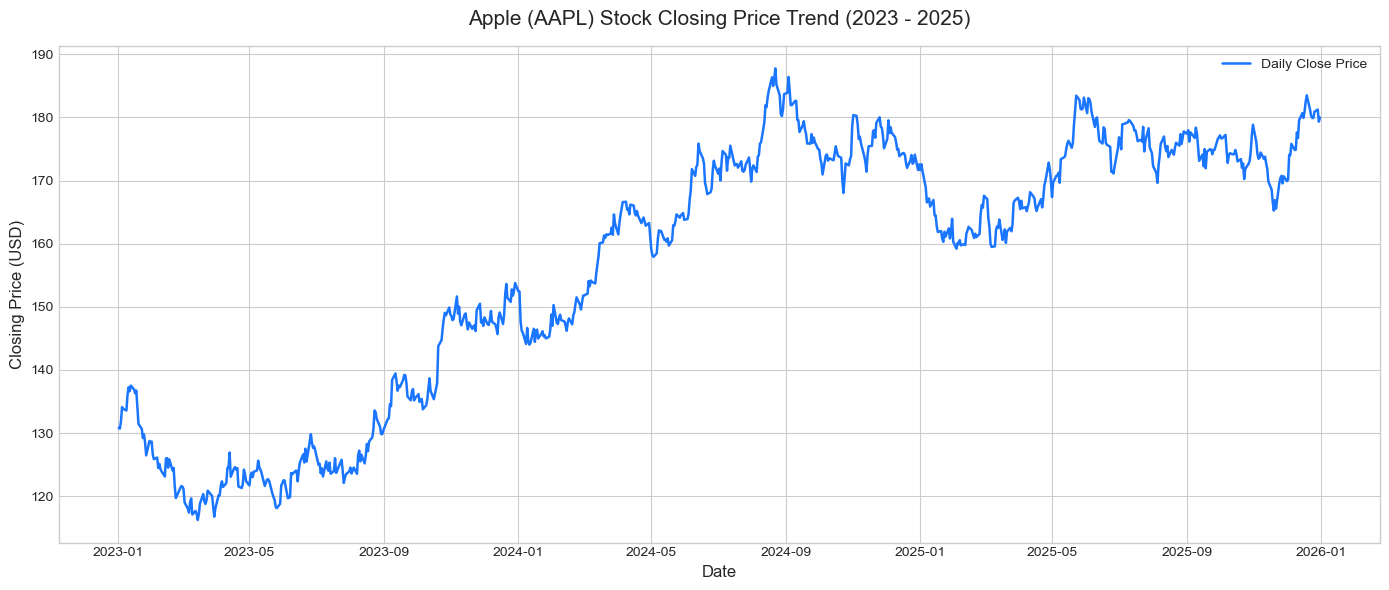

In [12]:
# %%
# Chart 1: 3-Year Apple Closing Price Trend
plt.figure(figsize=(14, 6), dpi=100)
plt.plot(data["Date"], data["Close"], color="#1a75ff", linewidth=1.8, label="Daily Close Price")

plt.title("Apple (AAPL) Stock Closing Price Trend (2023 - 2025)", fontsize=15, pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Closing Price (USD)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

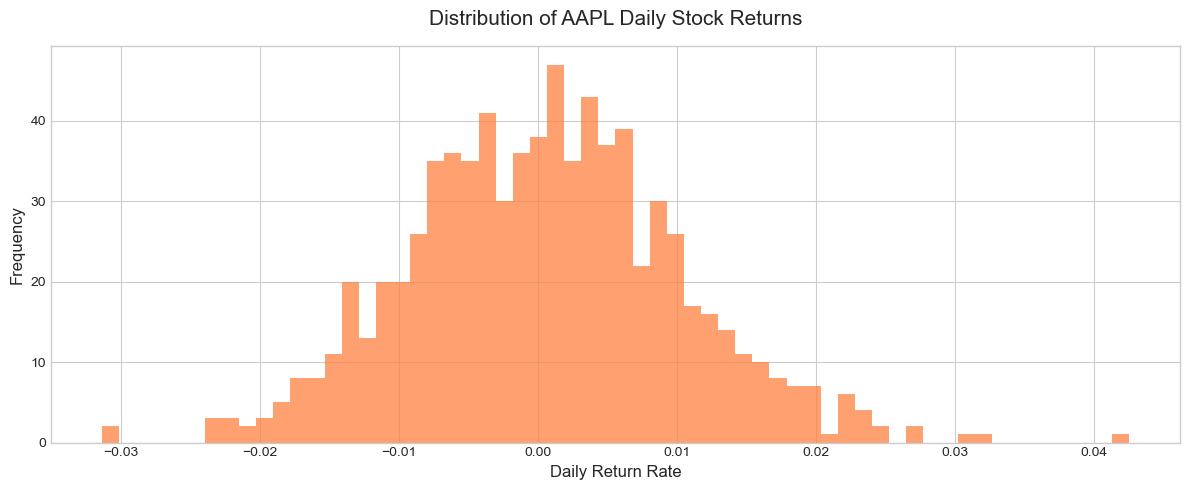

In [13]:
# %%
# Chart 2: Daily Return Volatility Distribution Histogram
plt.figure(figsize=(12, 5), dpi=100)
plt.hist(data["Daily_Return"].dropna(), bins=60, color="#ff8040", alpha=0.75)

plt.title("Distribution of AAPL Daily Stock Returns", fontsize=15, pad=15)
plt.xlabel("Daily Return Rate", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
# %% [markdown]
# ## 7. Final Analysis Conclusion & Insights
# 1. Over the 3-year observation period, Apple stock shows a **steady overall upward growth trend**
# 2. The average daily return is positive, proving long-term holding has stable appreciation potential
# 3. Daily price fluctuations follow a normal distribution, with most volatility staying within a reasonable range
# 4. Short-term investment carries risk of single-day sharp decline, long-term investment performance is more stable

In [15]:
# %% [markdown]
# ## 8. AI Usage Declaration (Required for Assignment)
# - AI Assistance Tool: ChatGPT
# - Assistance Content: Notebook structure optimization, code bug fixing, comment and academic expression polishing
# - Independent Work Statement: All core data logic, result interpretation and analysis conclusions are completed independently